In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from pathlib import Path

input_dir = Path("/kaggle/input")
for p in input_dir.iterdir():
    print(f"\n=== {p.name} ===")
    for f in list(p.rglob("*"))[:5]:   # 每个数据集只看前5个条目
        rel = f.relative_to(p)
        print(f"  {'[DIR]' if f.is_dir() else '[FILE]'} {rel}")
    print(f"  ... (共 {sum(1 for _ in p.rglob('*'))} 项)")


=== datasets ===
  [DIR] roxyjiang12180318
  [DIR] roxyjiang12180318/ultralytics-cbam-project
  [DIR] roxyjiang12180318/maizeleaf
  [DIR] roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project
  [FILE] roxyjiang12180318/ultralytics-cbam-project/kaggle_notebook_cell.py
  ... (共 4072 项)


In [4]:
!pip install -e /kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project -q

from ultralytics import YOLO

model = YOLO("/kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project/ultralytics/cfg/models/11/yolov11-cbam.yaml")

model.train(
    data="/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    amp=True,
    patience=30,
    save_period=10,
    project="/kaggle/working/yolo11-cbam-maize",
    name="exp",
    exist_ok=True,
)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build editable did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build editable ... error
error: subprocess-exited-with-error

× Getting requirements to build editable did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


ModuleNotFoundError: No module named 'ultralytics'

In [5]:
import sys

# 直接把项目源码加到 Python 路径里，跳过 pip install
code_dir = "/kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project"
sys.path.insert(0, code_dir)

# 确认路径里有没有 ultralytics 包
from pathlib import Path
p = Path(code_dir)
print("pyproject.toml:", (p / "pyproject.toml").exists())
print("ultralytics dir:", (p / "ultralytics").is_dir())

# 引入 YOLO
from ultralytics import YOLO

model = YOLO(f"{code_dir}/ultralytics/cfg/models/11/yolov11-cbam.yaml")

model.train(
    data="/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    amp=True,
    patience=30,
    save_period=10,
    project="/kaggle/working/yolo11-cbam-maize",
    name="exp",
    exist_ok=True,
)

pyproject.toml: True
ultralytics dir: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.90 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml, degrees=0.0, deterministic=True, device=0, dfl

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project/ultralytics/assets/bus.jpg'

In [ ]:
import sys

code_dir = "/kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project"
sys.path.insert(0, code_dir)

# 在 /tmp 创建测试图片绕过只读限制
import cv2
import numpy as np
from pathlib import Path

tmp_assets = Path("/tmp/ultralytics_assets")
tmp_assets.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(tmp_assets / "bus.jpg"), np.ones((640, 640, 3), dtype=np.uint8) * 128)

# 在所有层覆盖 ASSETS 指向临时目录
import ultralytics
ultralytics.ASSETS = tmp_assets

import ultralytics.utils
ultralytics.utils.ASSETS = tmp_assets

import ultralytics.utils.checks
ultralytics.utils.checks.ASSETS = tmp_assets

from ultralytics import YOLO

model = YOLO(f"{code_dir}/ultralytics/cfg/models/11/yolov11-cbam.yaml")

model.train(
    data="/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    amp=True,
    patience=30,
    save_period=10,
    project="/kaggle/working/yolo11-cbam-maize",
    name="exp",
    exist_ok=True,
)

WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.90 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, 

In [1]:
import sys, os, cv2
import numpy as np
from pathlib import Path

# 挂载代码路径 + 测试图片
code_dir = "/kaggle/input/datasets/roxyjiang12180318/ultralytics-cbam-project/ultralytics_cbam_project"
sys.path.insert(0, code_dir)

tmp_assets = Path("/tmp/ultralytics_assets")
tmp_assets.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(tmp_assets / "bus.jpg"), np.ones((640, 640, 3), dtype=np.uint8) * 128)

import ultralytics, ultralytics.utils, ultralytics.utils.checks
ultralytics.ASSETS = ultralytics.utils.ASSETS = ultralytics.utils.checks.ASSETS = tmp_assets

from ultralytics import YOLO

model = YOLO(f"{code_dir}/ultralytics/cfg/models/11/yolov11-cbam.yaml")

model.train(
    data="/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    amp=True,
    patience=30,
    save_period=10,
    project="/kaggle/working/yolo11-cbam-maize",
    name="exp",
    exist_ok=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.90 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/roxyjiang12180318/maizeleaf/AAAA/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eba6af41100>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

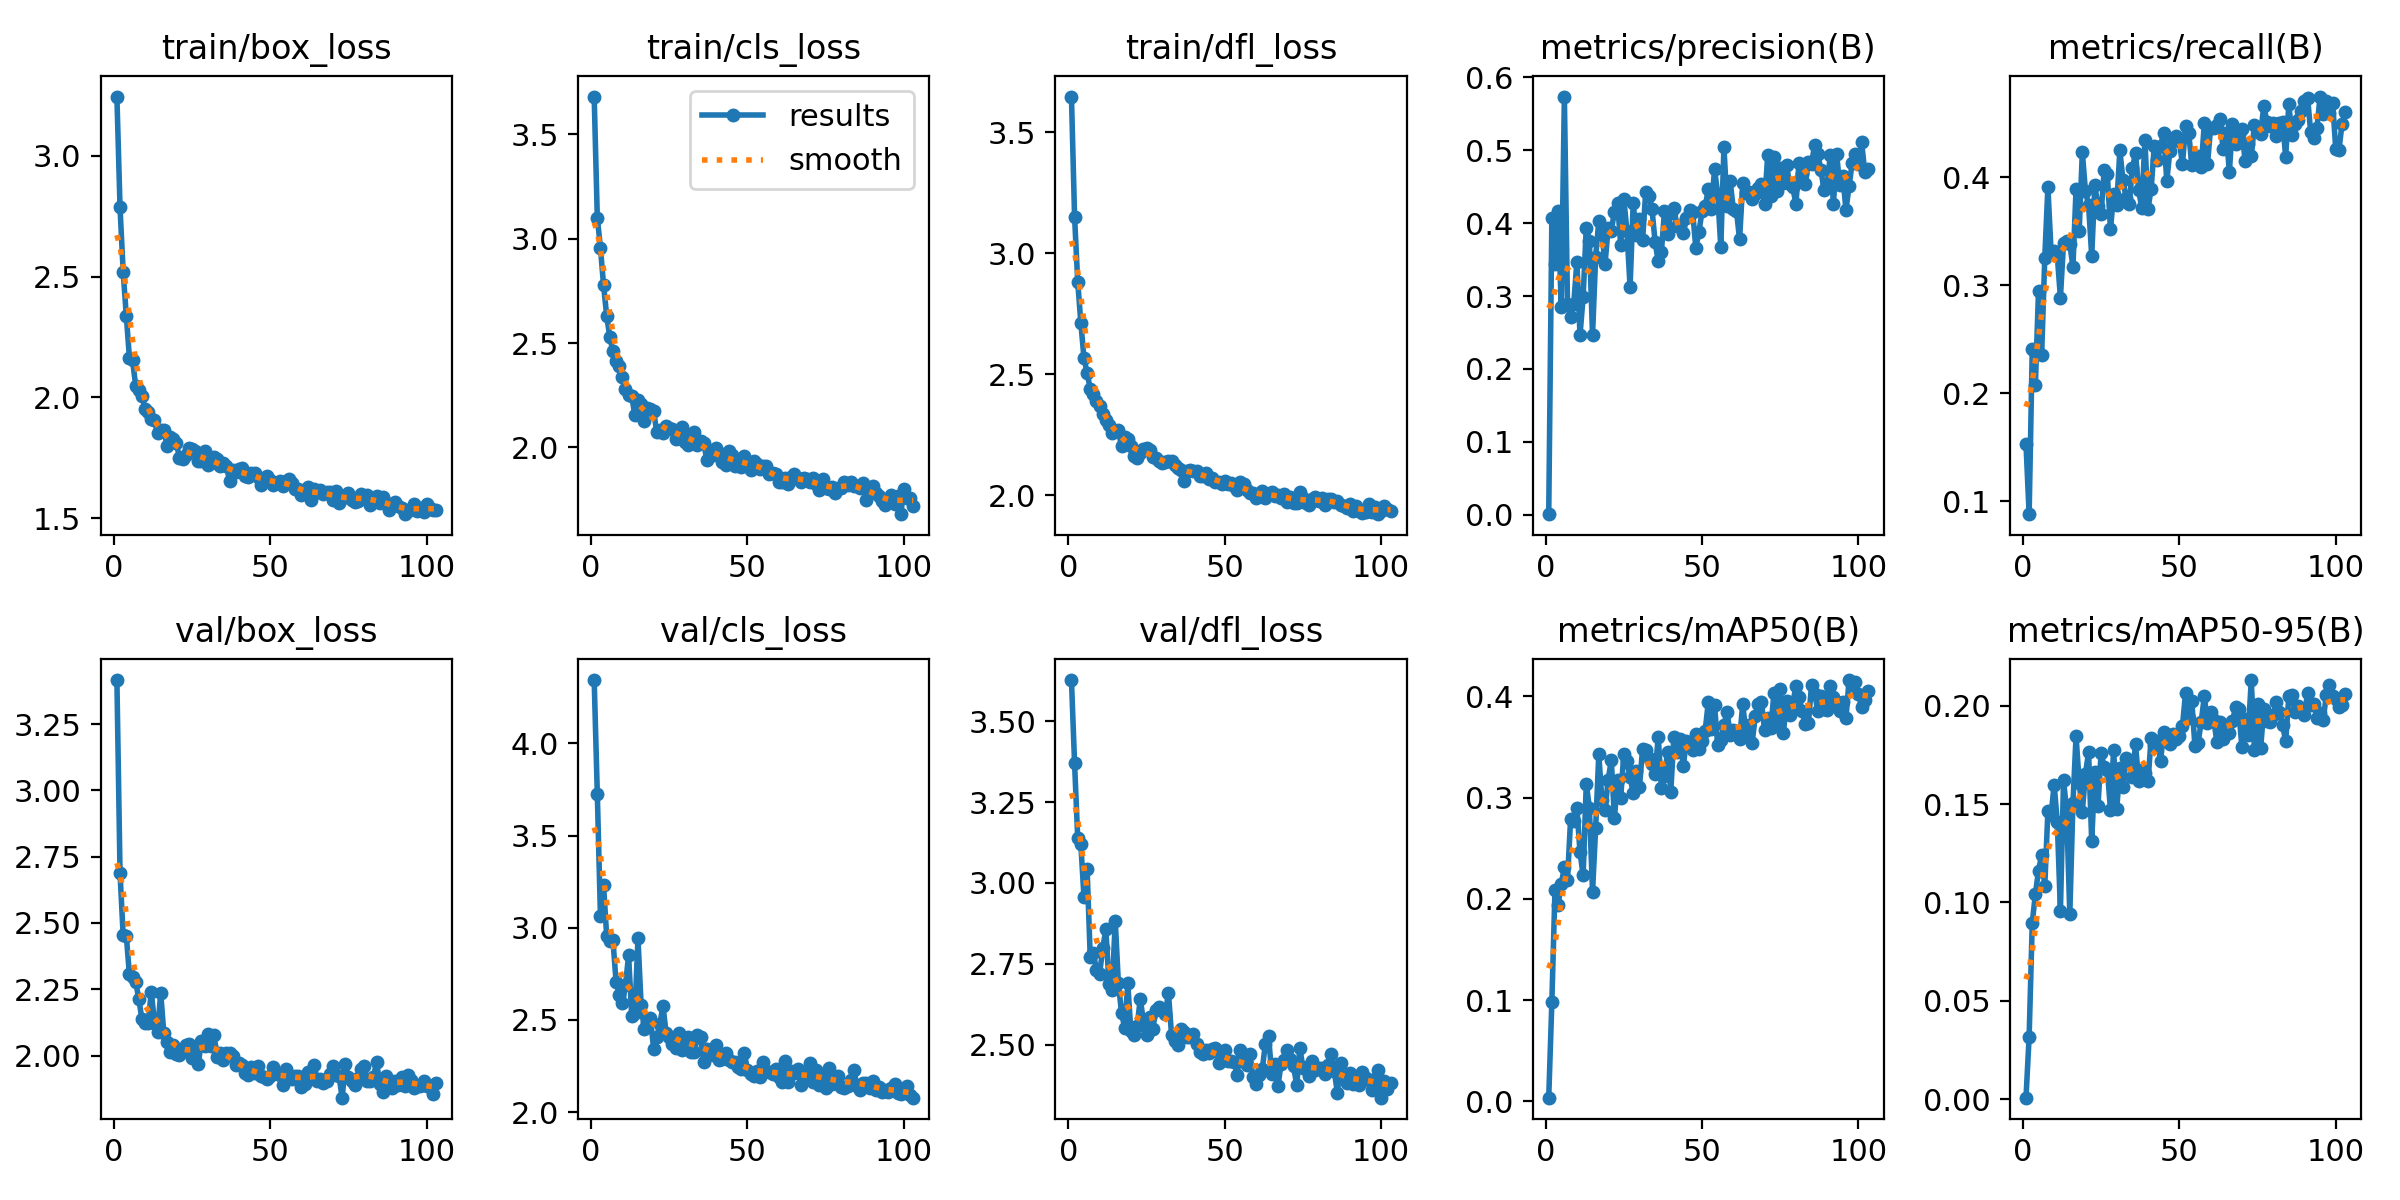

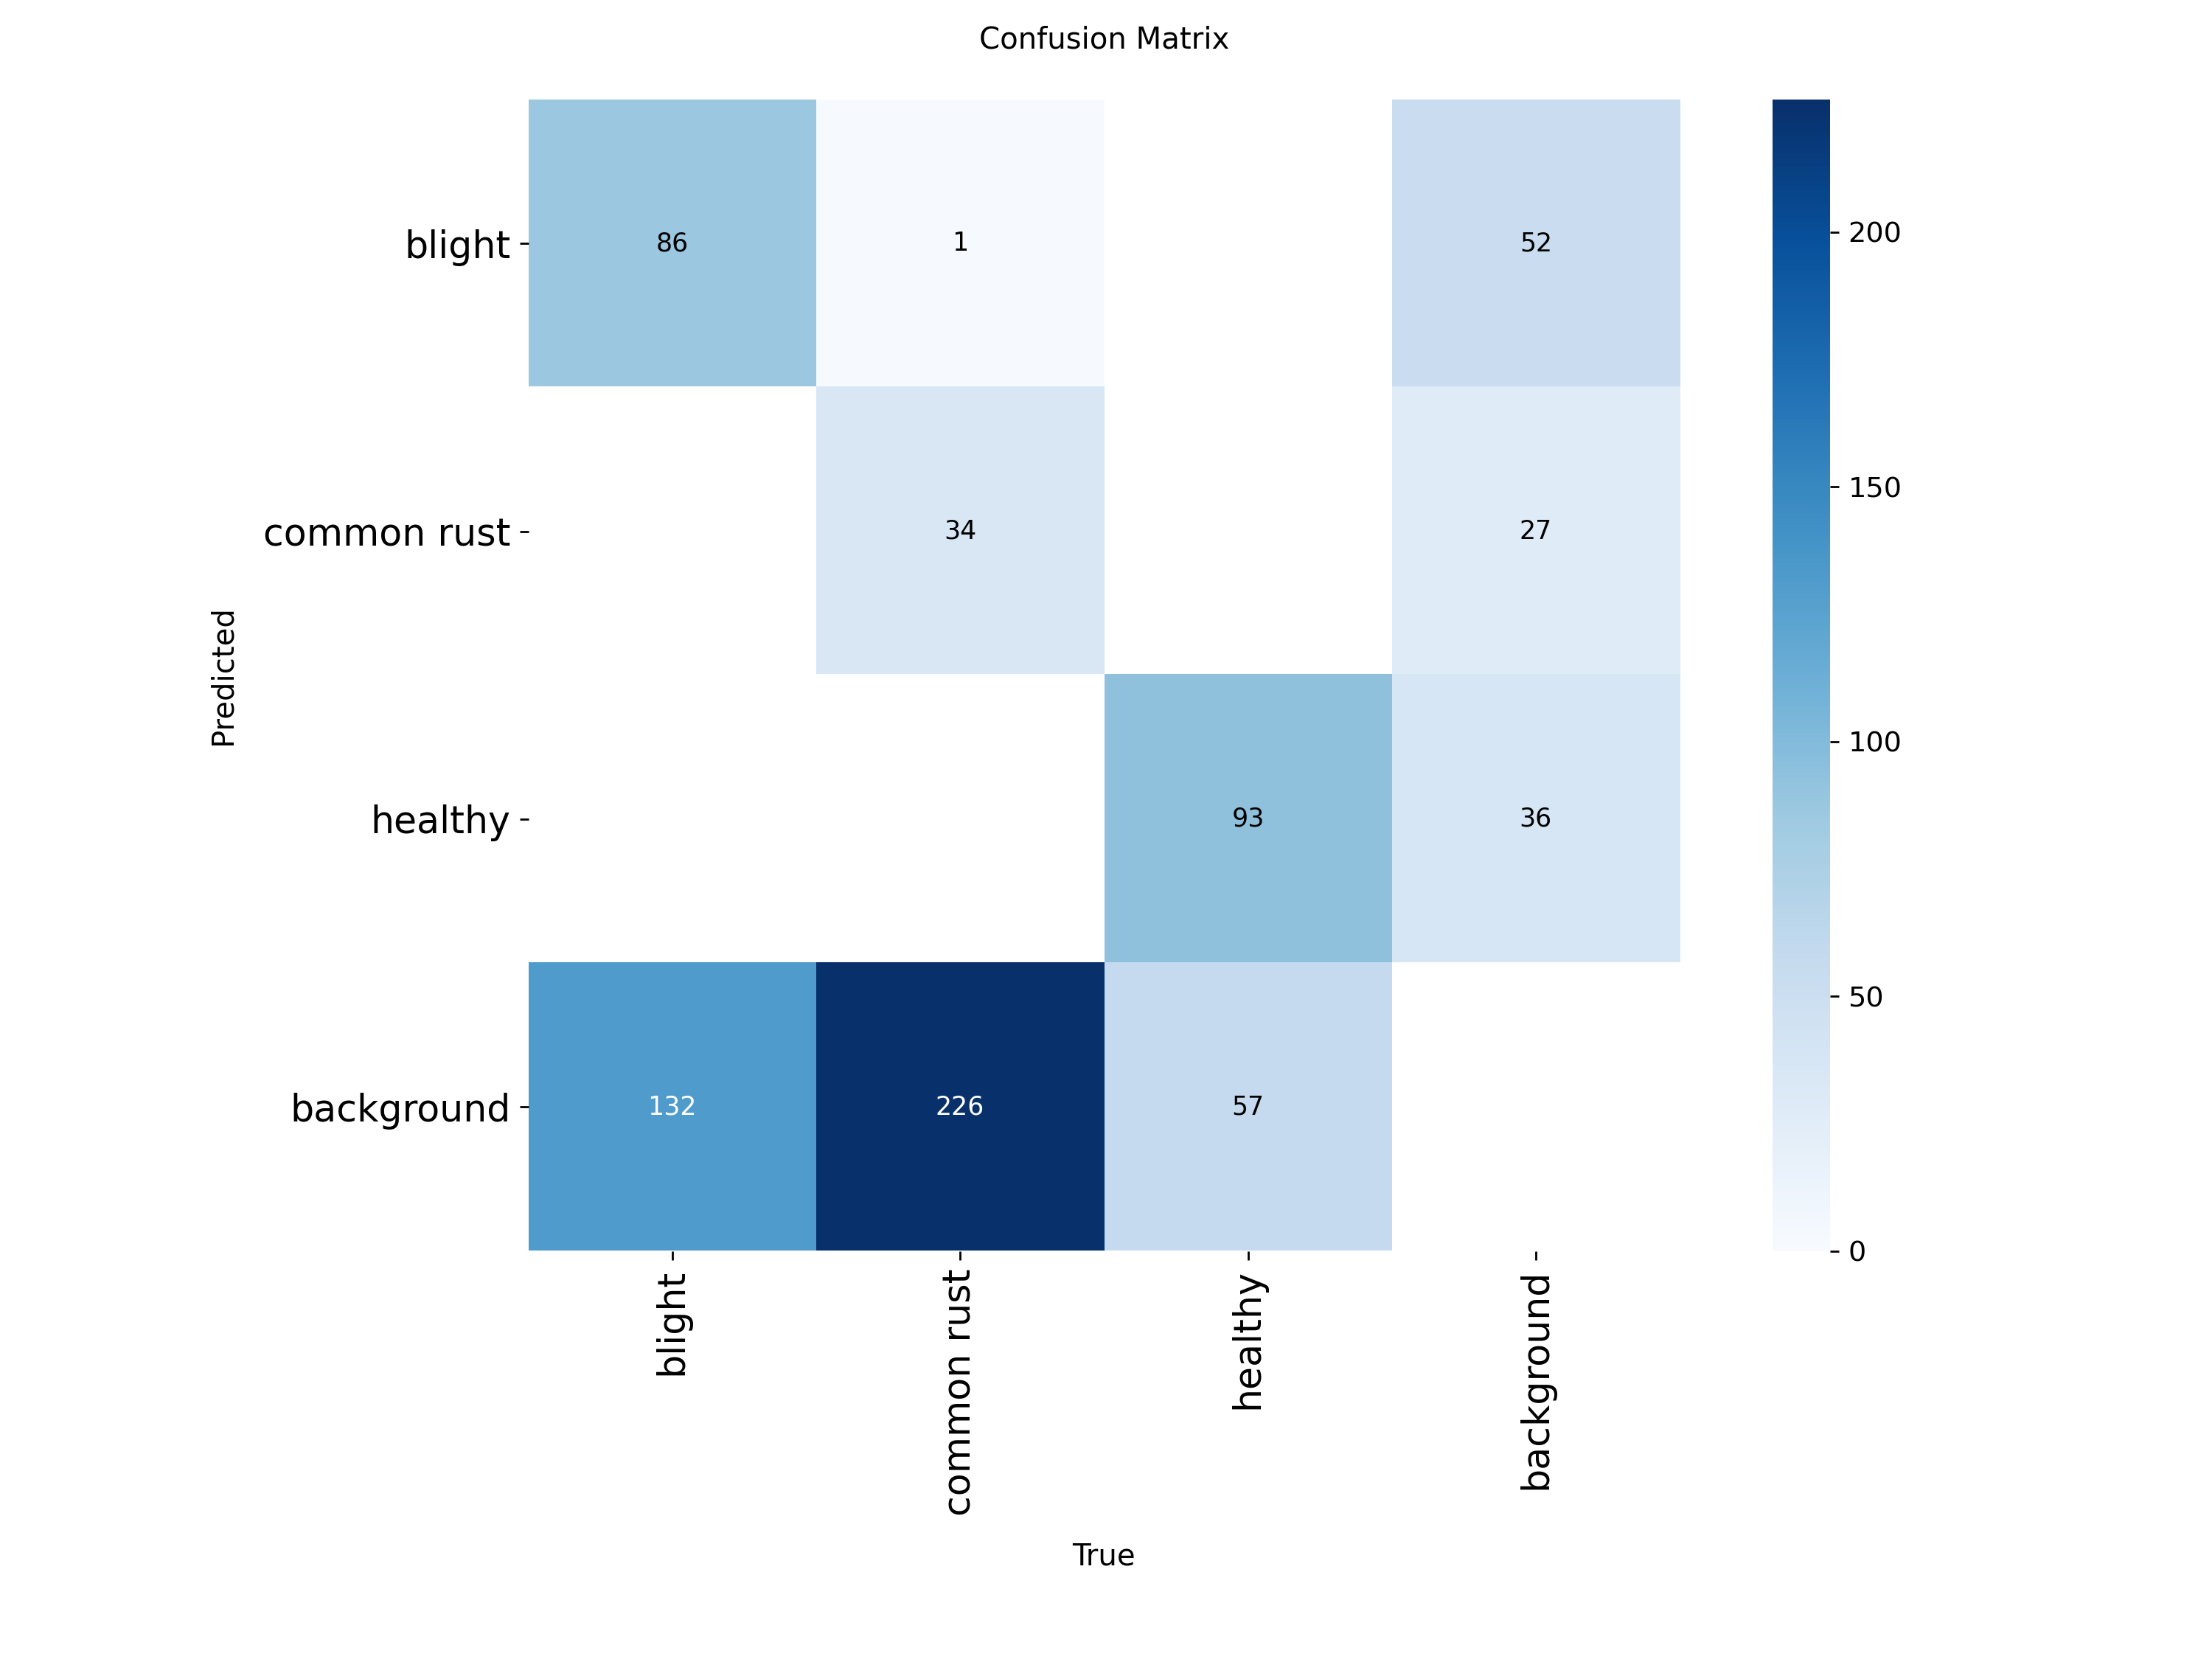

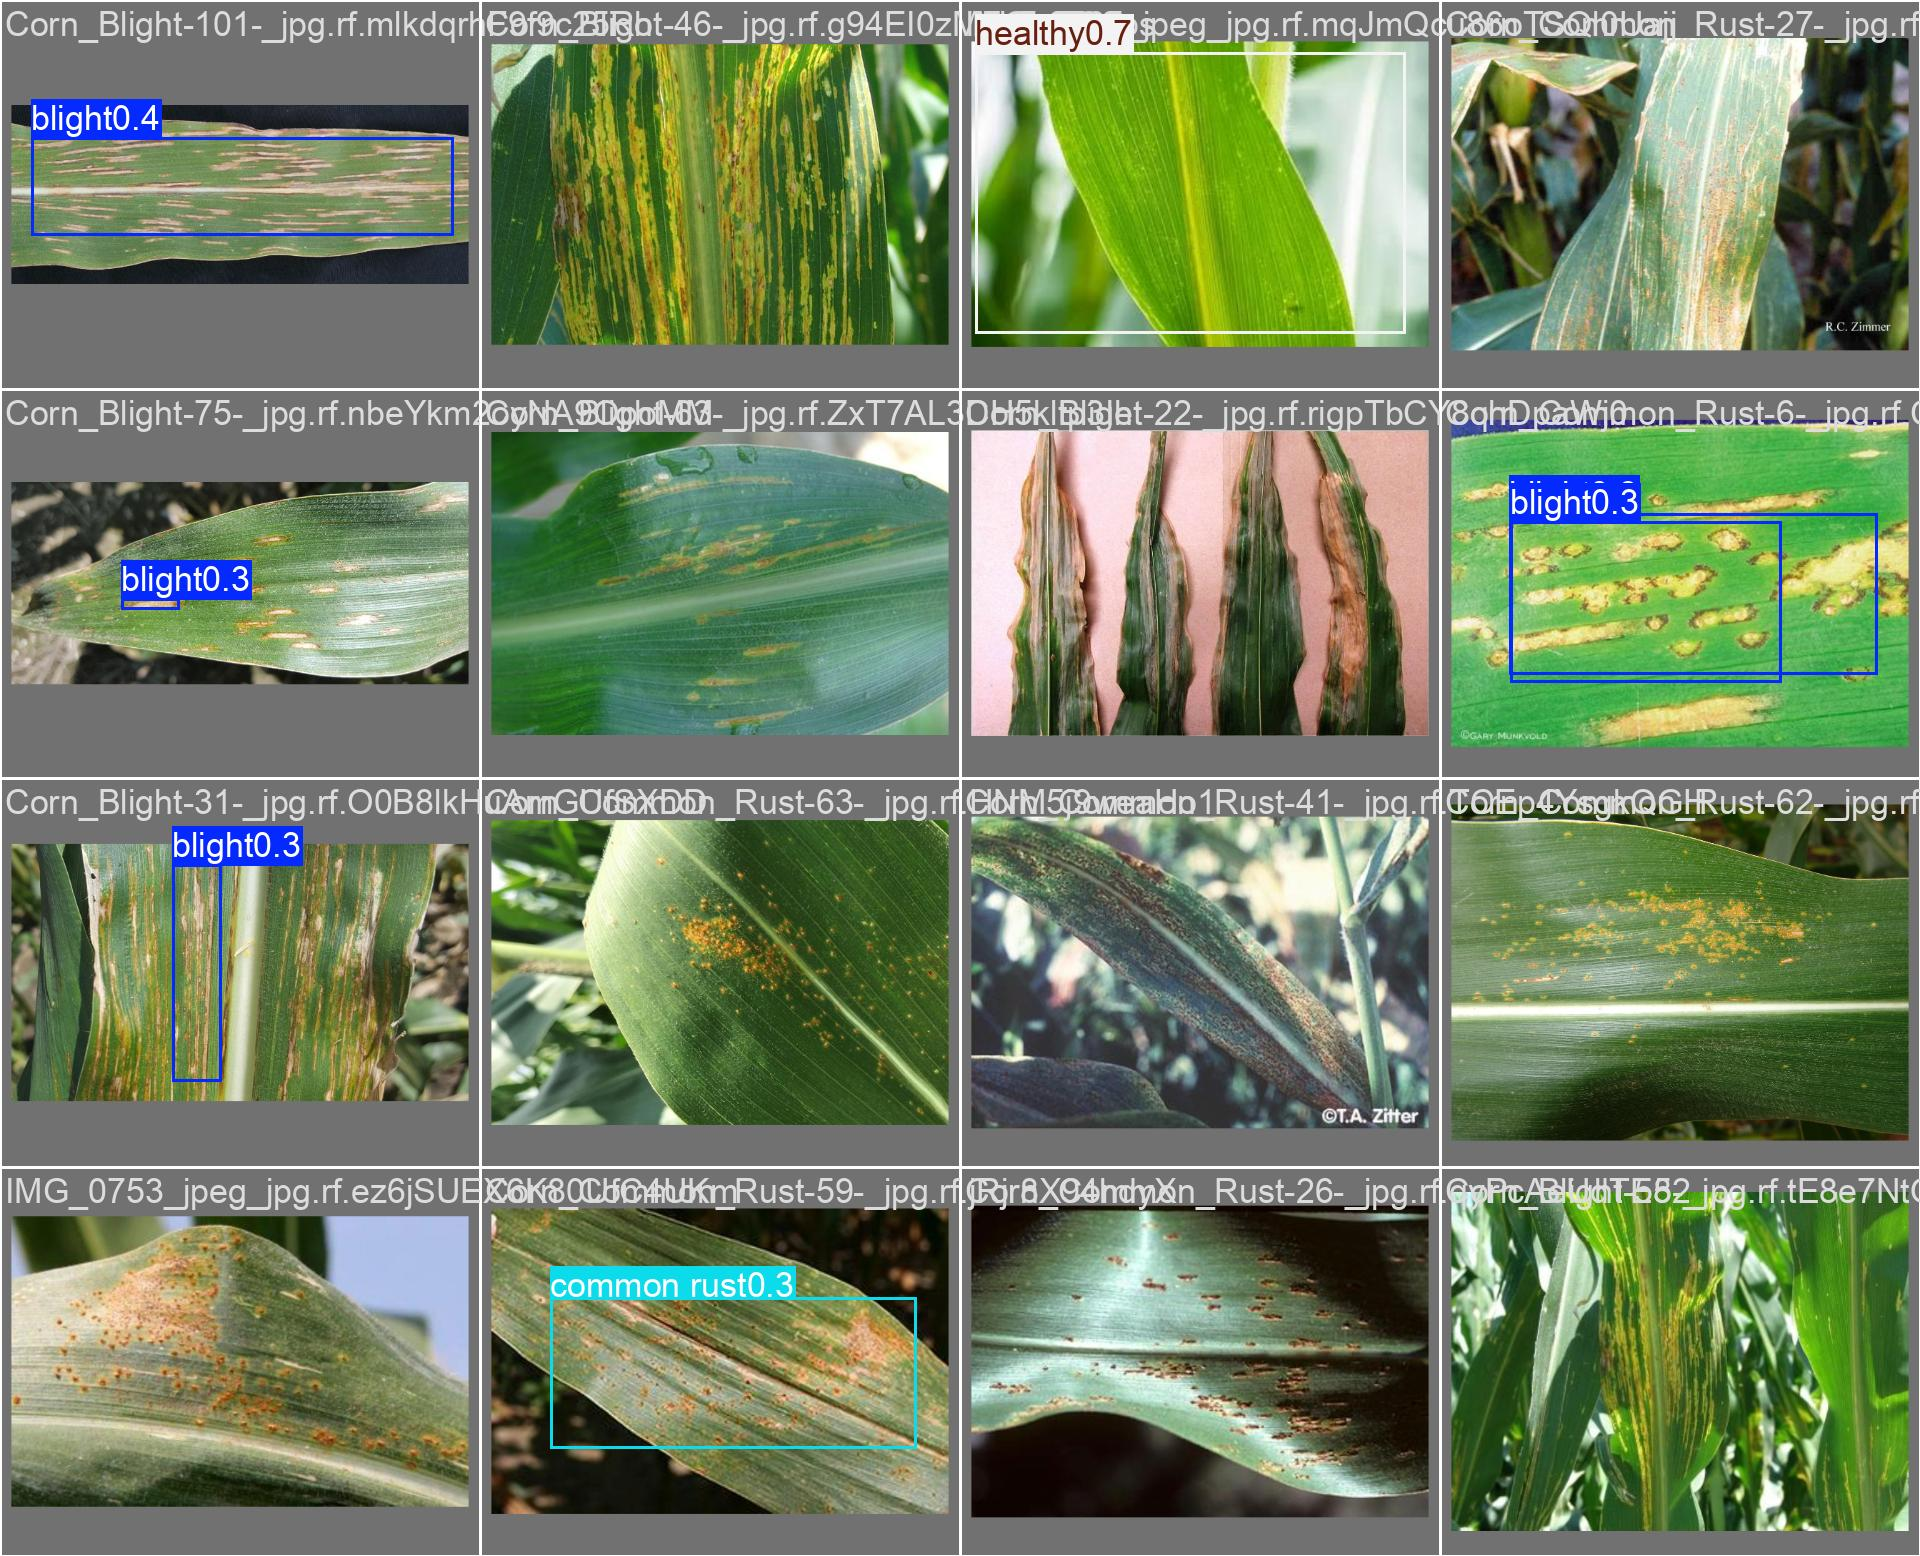

In [2]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

# 结果目录
exp_dir = "/kaggle/working/yolo11-cbam-maize/exp"

# 显示损失曲线
display(Image(filename=f"{exp_dir}/results.png"))

# 显示混淆矩阵
display(Image(filename=f"{exp_dir}/confusion_matrix.png"))

# 显示验证集预测样例
display(Image(filename=f"{exp_dir}/val_batch0_pred.jpg"))

In [4]:
import zipfile, os
from pathlib import Path

exp_dir = Path("/kaggle/working/yolo11-cbam-maize/exp")
zip_path = "/kaggle/working/yolo11-cbam-results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(exp_dir):
        for f in files:
            fp = Path(root) / f
            arcname = fp.relative_to(exp_dir.parent)
            zf.write(fp, arcname)

size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f"打包完成: {zip_path} ({size_mb:.1f} MB)")
print(f"包含 {len(zf.namelist())} 个文件")

打包完成: /kaggle/working/yolo11-cbam-results.zip (222.9 MB)
包含 32 个文件
